In [146]:
import re, time
import pandas as pd
import matplotlib.pyplot as plt

from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import WebDriverException
from selenium import webdriver
from selenium.webdriver.chrome.options import Options


In [147]:
BASE = "https://www.multitrabajos.com/listado-empresas?page={p}"
TOTAL_PAGINAS = 10
RE_AVISOS = re.compile(r"(\d+)\s+avisos?\s+activos?", re.IGNORECASE)
RE_EMPLEADOS = re.compile(r"Entre\s+(.+?)\s+empleados", re.IGNORECASE)


In [149]:
PROVINCIAS_EC = {
    "Azuay","Bolívar","Cañar","Carchi","Chimborazo","Cotopaxi","El Oro","Esmeraldas",
    "Galápagos","Guayas","Imbabura","Loja","Los Ríos","Manabí","Morona Santiago",
    "Napo","Orellana","Pastaza","Pichincha","Santa Elena","Santo Domingo de los Tsáchilas",
    "Sucumbíos","Tungurahua","Zamora Chinchipe"
}

In [150]:
def build_driver():
    options = Options()
    options.add_argument("--start-maximized")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--no-sandbox")
    return webdriver.Chrome(options=options)

In [151]:
def parse_card_text(text: str):
    lines = [ln.strip() for ln in text.split("\n") if ln.strip()]

    empresa = lines[0] if lines else None
    avisos = None
    empleados = None
    provincia = None
    actividad = None

    for ln in lines:
        m = RE_AVISOS.search(ln)
        if m:
            avisos = int(m.group(1))

        m2 = RE_EMPLEADOS.search(ln)
        if m2:
            empleados = m2.group(1).strip()

        if ln in PROVINCIAS_EC:
            provincia = ln

    
    for ln in lines:
        l = ln.lower()
        if ln == empresa:
            continue
        if "avisos" in l or "empleados" in l:
            continue
        if ln in PROVINCIAS_EC:
            continue
        if l in ("seguir", "empresa busca activamente"):
            continue
        if len(ln) <= 60:
            actividad = ln
            break

    return {
        "Empresa": empresa,
        "AvisosActivos": avisos,
        "Provincia": provincia,
        "Empleados": empleados
    }


In [ ]:
def extraer_pagina(driver, p, scrolls=2):
    url = BASE.format(p=p)
    driver.get(url)

    wait = WebDriverWait(driver, 25)
    wait.until(
        EC.presence_of_element_located(
            (By.XPATH, "//*[contains(., 'avisos activos') or contains(., 'avisos activo')]")
        )
    )
    time.sleep(2)

    for _ in range(scrolls):
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(2)

    cards = driver.find_elements(By.XPATH, "//a[contains(., 'avisos activos') or contains(., 'avisos activo')]")

    rows = []
    seen = set()
    for c in cards:
        t = c.text.strip()
        if not t or t in seen:
            continue
        seen.add(t)

        row = parse_card_text(t)
        rows.append(row)

    return rows


In [153]:
driver = build_driver()
todos = []

try:
    for p in range(1, TOTAL_PAGINAS + 1):
        print(f"Página {p}/{TOTAL_PAGINAS}")

        try:
            rows = extraer_pagina(driver, p, scrolls=2)
            print("  filas:", len(rows))
            todos.extend(rows)

        except WebDriverException as e:
            print("Driver se cayó. Recreando y reintentando 1 vez...")
            try:
                driver.quit()
            except Exception:
                pass
            driver = build_driver()

            rows = extraer_pagina(driver, p, scrolls=2)
            print("reintento OK | filas:", len(rows))
            todos.extend(rows)

finally:
    try:
        driver.quit()
    except Exception:
        pass

df_multi = pd.DataFrame(todos).drop_duplicates(subset=["Empresa"]).reset_index(drop=True)
df_multi.to_csv("multitrabajos_empresas.csv", index=False, encoding="utf-8-sig")
print("\n Guardado: multitrabajos_empresas.csv")

Página 1/10
  filas: 23
Página 2/10
  filas: 23
Página 3/10
  filas: 23
Página 4/10
  filas: 23
Página 5/10
  filas: 23
Página 6/10
  filas: 23
Página 7/10
  filas: 23
Página 8/10
  filas: 23
Página 9/10
  filas: 23
Página 10/10
  filas: 23

 Guardado: multitrabajos_empresas.csv


In [154]:
df_clean = df_multi.copy()

# limpiar texto
for col in ["Empresa","Provincia", "Empleados"]:
    df_clean[col] = df_clean[col].astype("string").str.strip()

# normalizar texto 
df_clean["Empresa"] = df_clean["Empresa"].fillna("No especificado")
df_clean["Provincia"] = df_clean["Provincia"].fillna("No especificado")

# avisos como int
df_clean["AvisosActivos"] = pd.to_numeric(df_clean["AvisosActivos"], errors="coerce").fillna(0).astype(int)

# empleados min/max
df_clean["Empleados_Min"] = df_clean["Empleados"].str.extract(r"(\d+)").astype(float)
df_clean["Empleados_Max"] = df_clean["Empleados"].str.extract(r"\d+\D+(\d+)").astype(float)

df_clean["Empleados_Min"] = df_clean["Empleados_Min"].fillna(0).astype(int)
df_clean["Empleados_Max"] = df_clean["Empleados_Max"].fillna(0).astype(int)

df_clean["Empleados_Promedio"] = df_clean[["Empleados_Min", "Empleados_Max"]].mean(axis=1)

df_clean.to_csv("multitrabajos_empresas_clean.csv", index=False, encoding="utf-8-sig")


print("\nTipos de dato:")
print(df_clean.dtypes)

print("\nNulos por columna:")
print(df_clean.isnull().sum())



Tipos de dato:
Empresa                string
AvisosActivos           int64
Provincia              string
Empleados              string
Page                    int64
Empleados_Min           int64
Empleados_Max           int64
Empleados_Promedio    float64
dtype: object

Nulos por columna:
Empresa                0
AvisosActivos          0
Provincia              0
Empleados             11
Page                   0
Empleados_Min          0
Empleados_Max          0
Empleados_Promedio     0
dtype: int64


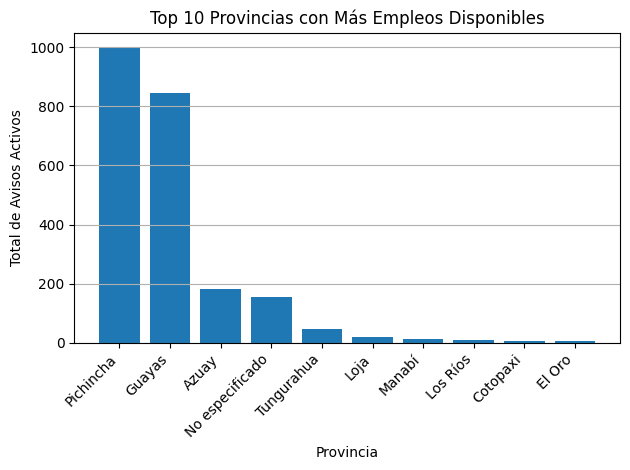

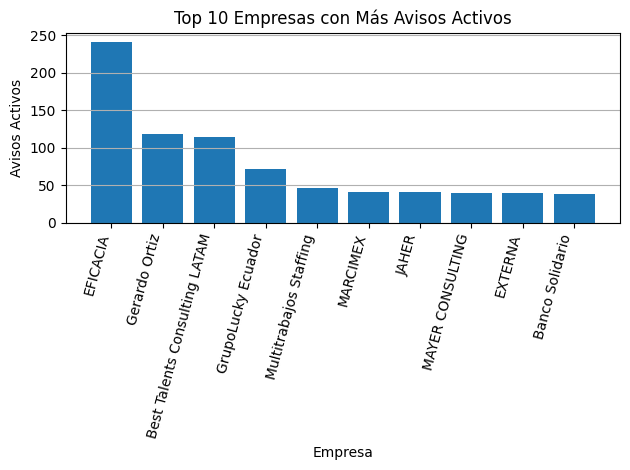

In [155]:
# Top 10 provincias por avisos activos
prov_empleos = (
    df_clean.groupby("Provincia")["AvisosActivos"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
plt.bar(prov_empleos.index.astype(str), prov_empleos.values)
plt.title("Top 10 Provincias con Más Empleos Disponibles")
plt.xlabel("Provincia")
plt.ylabel("Total de Avisos Activos")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

# Top 10 empresas por avisos activos
top_empresas = df_clean.sort_values(by="AvisosActivos", ascending=False).head(10)

plt.figure()
plt.bar(top_empresas["Empresa"].astype(str), top_empresas["AvisosActivos"].astype(int))
plt.title("Top 10 Empresas con Más Avisos Activos")
plt.xlabel("Empresa")
plt.ylabel("Avisos Activos")
plt.xticks(rotation=75, ha="right")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()